In [ ]:
!pip -q install torch torchvision numpy pandas scipy scikit-learn

In [ ]:
import os, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, stft
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, roc_curve, auc
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models import densenet121, DenseNet121_Weights

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE = "/content/drive/MyDrive/Colab Notebooks"

X = np.load(f"{BASE}/X_ptbxl_500hz.npy", mmap_mode="r")
print("X:", X.shape)   # (21799, 12, 5000)

df = pd.read_csv(f"{BASE}/ptbxl_database.csv")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]
class_to_idx = {c: i for i, c in enumerate(classes)}

Y = np.zeros((len(df), len(classes)), dtype=np.float32)
for i, codes in enumerate(df["scp_codes"]):
    for c in classes:
        if c in codes:
            Y[i, class_to_idx[c]] = 1.0

print("Y:", Y.shape)
print("Counts:", dict(zip(classes, Y.sum(axis=0).astype(int))))
assert X.shape[0] == Y.shape[0]

X: (21799, 12, 5000)
Y: (21799, 6)
Counts: {'NORM': np.int64(9514), 'IMI': np.int64(2676), 'ASMI': np.int64(2357), 'LVH': np.int64(2132), 'NDT': np.int64(1825), 'LAFB': np.int64(1623)}


In [ ]:
def bandpass_filter(x, fs=500, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, x, axis=0)

def ecg_to_spectrogram_tensor(ecg_time_leads, fs=500, win_len=256, hop=128, nfft=512, fmax=40.0):
    specs = []
    for lead in range(ecg_time_leads.shape[1]):
        f, tt, Z = stft(
            ecg_time_leads[:, lead],
            fs=fs,
            nperseg=win_len,
            noverlap=win_len - hop,
            nfft=nfft,
            boundary=None,
            padded=False
        )
        mag = np.abs(Z)
        keep = f <= fmax
        mag = mag[keep, :]
        mag = np.log1p(mag)
        mag = (mag - mag.mean()) / (mag.std() + 1e-8)
        specs.append(mag.astype(np.float32))
    return np.stack(specs, axis=0)   # (12, F, T)

In [ ]:
class PTBXLDenseNetDataset(Dataset):
    def __init__(self, X_mmap, Y, fs=500, out_size=224):
        self.X = X_mmap
        self.Y = Y
        self.fs = fs
        self.out_size = out_size

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        ecg = self.X[idx].T   # (5000, 12)

        ecg = bandpass_filter(ecg, fs=self.fs, low=0.5, high=40.0)
        ecg = (ecg - ecg.mean(axis=0)) / (ecg.std(axis=0) + 1e-8)

        spec = ecg_to_spectrogram_tensor(ecg, fs=self.fs)   # (12, 41, 38)
        x = torch.from_numpy(spec)

        x = x.unsqueeze(0)   # (1, 12, 41, 38)
        x = F.interpolate(x, size=(self.out_size, self.out_size), mode="bilinear", align_corners=False)
        x = x.squeeze(0)     # (12, 224, 224)

        y = torch.from_numpy(self.Y[idx]).float()
        return x, y

In [ ]:
idx_all = np.arange(X.shape[0])
train_idx, val_idx = train_test_split(idx_all, test_size=0.2, random_state=42)

train_ds = torch.utils.data.Subset(PTBXLDenseNetDataset(X, Y), train_idx)
val_ds   = torch.utils.data.Subset(PTBXLDenseNetDataset(X, Y), val_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
def make_densenet121_12ch(num_classes=6):
    weights = DenseNet121_Weights.IMAGENET1K_V1
    model = densenet121(weights=weights)

    old_conv = model.features.conv0   # Conv2d(3, 64, ...)
    new_conv = nn.Conv2d(
        in_channels=12,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    with torch.no_grad():
        w = old_conv.weight   # (64, 3, 7, 7)
        w_mean = w.mean(dim=1, keepdim=True)   # (64, 1, 7, 7)
        new_conv.weight.copy_(w_mean.repeat(1, 12, 1, 1))

    model.features.conv0 = new_conv

    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)

    return model

device = "cuda" if torch.cuda.is_available() else "cpu"
model = make_densenet121_12ch(num_classes=len(classes)).to(device)

criterion = nn.BCEWithLogitsLoss()
print("Device:", device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 144MB/s]


Device: cuda


In [ ]:
for name, p in model.named_parameters():
    p.requires_grad = ("classifier" in name)

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

In [ ]:
def run_epoch(model, loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0

    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def get_outputs(model, loader):
    model.eval()
    all_true, all_prob = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        probs = torch.sigmoid(model(xb)).cpu().numpy()
        all_prob.append(probs)
        all_true.append(yb.numpy())

    return np.vstack(all_true), np.vstack(all_prob)

In [ ]:
print("\n--- Warm-up training (classifier only) ---")
for epoch in range(1, 3):
    tr_loss = run_epoch(model, train_loader, training=True)
    va_loss = run_epoch(model, val_loader, training=False)
    print(f"Warm-up Epoch {epoch}: train_loss={tr_loss:.4f} val_loss={va_loss:.4f}")


--- Warm-up training (classifier only) ---
Warm-up Epoch 1: train_loss=0.3482 val_loss=0.3259
Warm-up Epoch 2: train_loss=0.3244 val_loss=0.3170


In [ ]:
for p in model.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("\n--- Fine-tuning full DenseNet121 ---")
for epoch in range(1, 30):
    tr_loss = run_epoch(model, train_loader, training=True)
    va_loss = run_epoch(model, val_loader, training=False)
    print(f"Fine-tune Epoch {epoch}: train_loss={tr_loss:.4f} val_loss={va_loss:.4f}")


--- Fine-tuning full DenseNet121 ---
Fine-tune Epoch 1: train_loss=0.2307 val_loss=0.2249
Fine-tune Epoch 2: train_loss=0.2060 val_loss=0.2247
Fine-tune Epoch 3: train_loss=0.1827 val_loss=0.2231
Fine-tune Epoch 4: train_loss=0.1578 val_loss=0.2302
Fine-tune Epoch 5: train_loss=0.1278 val_loss=0.2500
Fine-tune Epoch 6: train_loss=0.0937 val_loss=0.2909
Fine-tune Epoch 7: train_loss=0.0653 val_loss=0.2969
Fine-tune Epoch 8: train_loss=0.0482 val_loss=0.3271
Fine-tune Epoch 9: train_loss=0.0358 val_loss=0.3740
Fine-tune Epoch 10: train_loss=0.0319 val_loss=0.3862
Fine-tune Epoch 11: train_loss=0.0290 val_loss=0.3981
Fine-tune Epoch 12: train_loss=0.0263 val_loss=0.3934
Fine-tune Epoch 13: train_loss=0.0232 val_loss=0.4283
Fine-tune Epoch 14: train_loss=0.0232 val_loss=0.4123
Fine-tune Epoch 15: train_loss=0.0197 val_loss=0.4418
Fine-tune Epoch 16: train_loss=0.0213 val_loss=0.4767
Fine-tune Epoch 17: train_loss=0.0175 val_loss=0.4681
Fine-tune Epoch 18: train_loss=0.0173 val_loss=0.4618

In [ ]:
y_true, y_prob = get_outputs(model, val_loader)
y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
avg_epoch_time = 8.5   ##example (seconds)
epochs = 29

total_time = avg_epoch_time * epochs

print(f"Approx Total Time: {total_time:.2f} seconds")
print(f"Approx Total Time: {total_time/60:.2f} minutes")

Approx Total Time: 246.50 seconds
Approx Total Time: 4.11 minutes


In [ ]:
print("\nOverall Metrics (DenseNet121)\n")
print("Macro Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))

print("Micro Precision:", precision_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred, average="micro", zero_division=0))


Overall Metrics (DenseNet121)

Macro Precision: 0.6053498555663412
Macro Recall   : 0.5477241074327258
Macro F1       : 0.5705133045735209
Micro Precision: 0.6912681912681913
Micro Recall   : 0.6626806178375685
Micro F1       : 0.676672602391249


In [ ]:
print("\nPer-Class Metrics (DenseNet121)\n")
for k, name in enumerate(classes):
    precision = precision_score(y_true[:, k], y_pred[:, k], zero_division=0)
    recall    = recall_score(y_true[:, k], y_pred[:, k], zero_division=0)
    f1        = f1_score(y_true[:, k], y_pred[:, k], zero_division=0)
    acc       = accuracy_score(y_true[:, k], y_pred[:, k])

    print(f"{name}:")
    print(f"  Precision = {precision:.4f}")
    print(f"  Recall    = {recall:.4f}")
    print(f"  F1-score  = {f1:.4f}")
    print(f"  Accuracy  = {acc:.4f}")
    print("-" * 40)


Per-Class Metrics (DenseNet121)

NORM:
  Precision = 0.8028
  Recall    = 0.8547
  F1-score  = 0.8279
  Accuracy  = 0.8413
----------------------------------------
IMI:
  Precision = 0.4654
  Recall    = 0.4143
  F1-score  = 0.4383
  Accuracy  = 0.8736
----------------------------------------
ASMI:
  Precision = 0.6635
  Recall    = 0.5732
  F1-score  = 0.6150
  Accuracy  = 0.9202
----------------------------------------
LVH:
  Precision = 0.5522
  Recall    = 0.3240
  F1-score  = 0.4084
  Accuracy  = 0.9156
----------------------------------------
NDT:
  Precision = 0.4126
  Recall    = 0.4286
  F1-score  = 0.4204
  Accuracy  = 0.9089
----------------------------------------
LAFB:
  Precision = 0.7357
  Recall    = 0.6916
  F1-score  = 0.7130
  Accuracy  = 0.9573
----------------------------------------


In [ ]:
per_class_acc = []
for k, name in enumerate(classes):
    acc = accuracy_score(y_true[:, k], y_pred[:, k])
    per_class_acc.append(acc)

macro_accuracy = np.mean(per_class_acc)
print("\nMacro Accuracy:", macro_accuracy)


Macro Accuracy: 0.90282874617737


In [ ]:
print("\nAUROC per Class\n")
aucs = []
for k, name in enumerate(classes):
    if len(np.unique(y_true[:, k])) < 2:
        print(f"{name}: AUROC not defined")
        continue
    auc_k = roc_auc_score(y_true[:, k], y_prob[:, k])
    aucs.append(auc_k)
    print(f"{name}: AUROC = {auc_k:.4f}")

print("\nMacro AUROC:", np.mean(aucs))


AUROC per Class

NORM: AUROC = 0.9189
IMI: AUROC = 0.8452
ASMI: AUROC = 0.9234
LVH: AUROC = 0.8336
NDT: AUROC = 0.8442
LAFB: AUROC = 0.9632

Macro AUROC: 0.8881065132479149


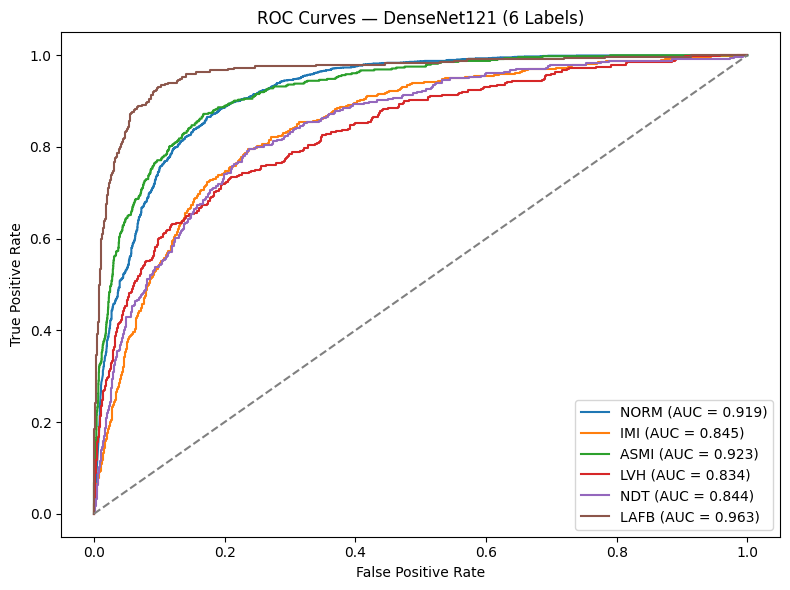

In [ ]:
plt.figure(figsize=(8, 6))

for k, name in enumerate(classes):
    if len(np.unique(y_true[:, k])) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_true[:, k], y_prob[:, k])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — DenseNet121 (6 Labels)")
plt.legend()
plt.tight_layout()
plt.savefig("roc_densenet121.png", dpi=300)
plt.show()